In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from numpy import cos,pi,sqrt,log10
from astropy.table import Table
from astropy.table import unique
import os
import ctadata
from astropy.io import ascii
from scipy import stats
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit, least_squares, nnls, brentq


In [2]:
data_folder = "./LST_data/"
DL3_folder = "/pnfs/cta.cscs.ch/lst/DL3/"
run_catalog=ascii.read(data_folder + 'LST_source_catalog.ecsv')

In [3]:
e_bins=np.logspace(np.log10(0.01), np.log10(10), 11)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,34)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

In [26]:
def find_and_process_files(runlist, gheff, 
                          ra_obj, dec_obj, bkg_subtraction_radius,
                          e_mins, e_maxs, e, th2_bins,
                          cts_s, cts_b, t_expo):
    pointing_sep_avg = 0
    pointing_sep_counter = 0
    counter = 0

    n_energy_bins = len(e)
    n_theta_bins = len(th2_bins) - 1
    
    cts_effarea_corr = np.zeros(
        (n_energy_bins, n_theta_bins),
        dtype=float
    )
    
    cts_effarea_corr_err = np.zeros(
        (n_energy_bins, n_theta_bins),
        dtype=float
    )
    
    for ind in range(len(runlist)):
        r = runlist[ind]
        for i in range(len(run_catalog)):
            run = run_catalog[i]['Run ID']
            if run == r:
                date = run_catalog[i]['Date directory'].replace('-', '')
                vers = ctadata.list_dir(DL3_folder + date)
                for ver in vers:
                    if ver[0] == 'v':
                        tailcuts = ctadata.list_dir(DL3_folder + date + '/' + ver)
                        for tailcut in tailcuts:
                            nsbs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut)
                            for nsb in nsbs:
                                versions = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb)
                                for version in versions:
                                    tags = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std')
                                    for tag in tags:
                                        src_dependences = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag)
                                        for src_dep in src_dependences:
                                            point_or_full = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep)
                                            for p_f in point_or_full:
                                                wobbles = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f)
                                                for wob in wobbles:
                                                    gheffs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob)
                                                    for gh in gheffs:
                                                        if gheff in gh:
                                                            irfs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh)
                                                            for irf in irfs:
                                                                files = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh + '/' + irf)
                                                                
                                                                if run < 10000:
                                                                    fname = 'dl3_LST-1.Run0' + str(run) + '.fits'
                                                                else:
                                                                    fname = 'dl3_LST-1.Run' + str(run) + '.fits'
                                                                
                                                                if fname in files:
                                                                    file_path = DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh + '/' + irf + '/' + fname
                                                                    ctadata.fetch_and_save_file_or_dir(file_path)
                                                                    
                                                                    with fits.open(fname) as hdul:
                                                                        header = hdul[1].header
                                                                        dat = header['DATE-OBS']
                                                                        t_expo += header['LIVETIME']
                                                                        print(ind, date, fname, header['LIVETIME'])
                                                                        
                                                                        ra_pnt = header['RA_PNT']
                                                                        dec_pnt = header['DEC_PNT']
                                                                        dra = ra_obj - ra_pnt
                                                                        ddec = dec_obj - dec_pnt
                                                                        
                                                                        ra_bkg = ra_pnt - dra
                                                                        dec_bkg = dec_pnt - ddec
                                                                        coords_bkg = SkyCoord(ra_bkg, dec_bkg, unit='degree')
                                                                        coords_obj = SkyCoord(ra_obj, dec_obj, unit='degree')

                                                                        sep_pnt = SkyCoord(ra_pnt, dec_pnt, unit='degree').separation(coords_obj).deg
                                                                        pointing_sep_counter += 1
                                                                        pointing_sep_avg += sep_pnt
                                                                        
                                                                        events = hdul['EVENTS'].data
                                                                        coords = SkyCoord(events['RA'], events['DEC'], unit='degree')
                                                                        
                                                                        seps = coords.separation(coords_obj).deg
                                                                        seps_b = coords.separation(coords_bkg).deg
                                                                        energies = events['ENERGY']

                                                                        effarea_hdu = hdul['EFFECTIVE AREA'].data
                                                                        effarea = effarea_hdu["EFFAREA"] * 100**2 # m2 to cm2
                                                                        effareas_ebins_mean = np.sqrt(effarea_hdu["ENERG_LO"] * effarea_hdu["ENERG_HI"])

                                                                        cts_effarea_corr_tmp = np.zeros_like(cts_effarea_corr)
                                                                        cts_effarea_corr_err_tmp = np.zeros_like(cts_effarea_corr_err)
                                                                        for i in range(len(e)):
                                                                            m_s = (energies > e_mins[i]) * (energies < e_maxs[i]) * (seps < bkg_subtraction_radius)
                                                                            h_s = np.histogram(seps[m_s]**2, bins=th2_bins)
                                                                            
                                                                            m_b = (energies > e_mins[i]) * (energies < e_maxs[i]) * (seps_b < bkg_subtraction_radius)
                                                                            h_b = np.histogram(seps_b[m_b]**2, bins=th2_bins)
                                                                            
                                                                            cts_s[i] += h_s[0]
                                                                            cts_b[i] += h_b[0]
                                                                    
                                                                            # If using this remember to square the error after the fuction.
                                                                            effarea_usable_ind = np.argmin(np.abs(e[i] * np.ones(effareas_ebins_mean.shape[0]) - effareas_ebins_mean))
                                                                            cts_effarea_corr_tmp[i] += (h_s[0] - h_b[0]) / effarea[0][0][effarea_usable_ind]
                                                                            cts_effarea_corr_err_tmp[i] += (h_s[0] + h_b[0]) / effarea[0][0][effarea_usable_ind]**2

                                                                        cts_effarea_corr += cts_effarea_corr_tmp
                                                                        cts_effarea_corr_err += cts_effarea_corr_err_tmp
                                                                        
                                                                    os.remove(fname)
                                                                    counter += 1
                                                                    if counter >= countermax:
                                                                        cts_effarea_corr_err = np.sqrt(cts_effarea_corr_err)
                                                                        pointing_sep_avg /= pointing_sep_counter
    
                                                                        return cts_s, cts_b, t_expo, pointing_sep_avg, cts_effarea_corr, cts_effarea_corr_err
    cts_effarea_corr_err = np.sqrt(cts_effarea_corr_err)
    pointing_sep_avg /= pointing_sep_counter
    
    return cts_s, cts_b, t_expo, pointing_sep_avg, cts_effarea_corr, cts_effarea_corr_err

**BLAZAR**

In [27]:
Name = "Mrk501"
runlist = np.load(data_folder + 'good_runs_' + Name + '_Zd_30.0.npy')
gheff='gheff0.9'
Zdcut=30

coords_obj=SkyCoord.from_name(Name)
ra_obj=coords_obj.icrs.ra.deg
dec_obj=coords_obj.icrs.dec.deg
ra_obj,dec_obj
cdec=cos(dec_obj*pi/180.)

In [28]:
countermax = 50
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

cts_s, cts_b, t_expo, pointing_seps_avg, cts_effarea_corr, cts_effarea_corr_err = find_and_process_files(
    runlist=runlist,
    gheff=gheff,
    ra_obj=ra_obj,
    dec_obj=dec_obj,
    bkg_subtraction_radius=bkg_subtraction_radius,
    e_mins=e_mins,
    e_maxs=e_maxs,
    e=e,
    th2_bins=th2_bins,
    cts_s=cts_s,
    cts_b=cts_b,
    t_expo=t_expo,
)
print(f"Total exposure: {t_expo/3600}h")

0 20210317 dl3_LST-1.Run04139.fits 1130.0273713094493


AttributeError: 'BinTableHDU' object has no attribute 'evaluate'

**SED**

(1e-14, 5e-10)

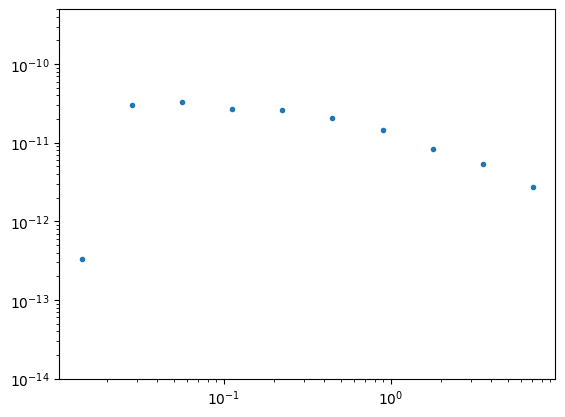

In [14]:
sed = e**2 * cts_effarea_corr.sum(axis=1) / de / t_expo
plt.plot(e, sed, ".")
plt.xscale("log")
plt.yscale("log")
plt.ylim([1e-14, 5e-10])

**PSF**

In [ ]:
psf_params = np.load("../crab_fit.npy", allow_pickle=True)

**UL**

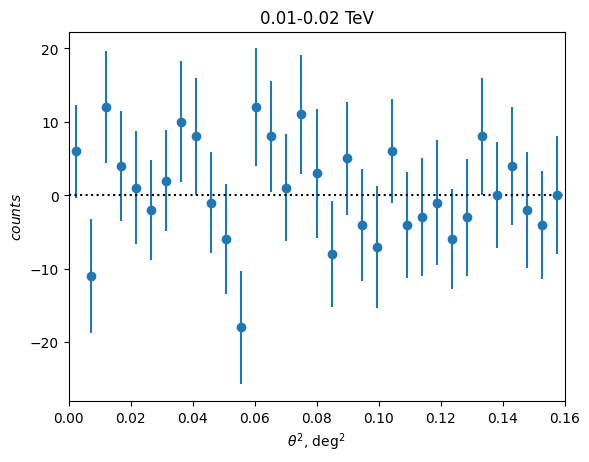

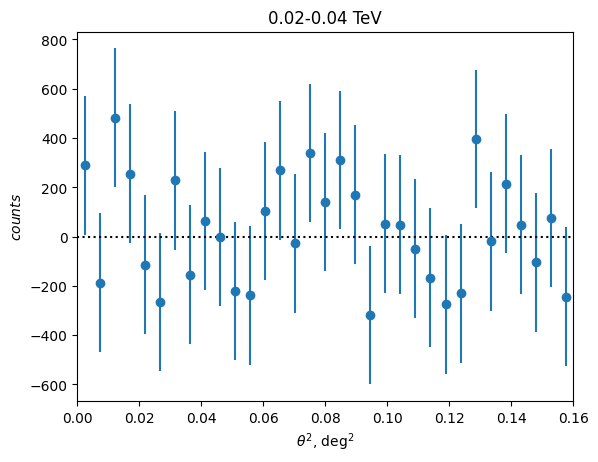

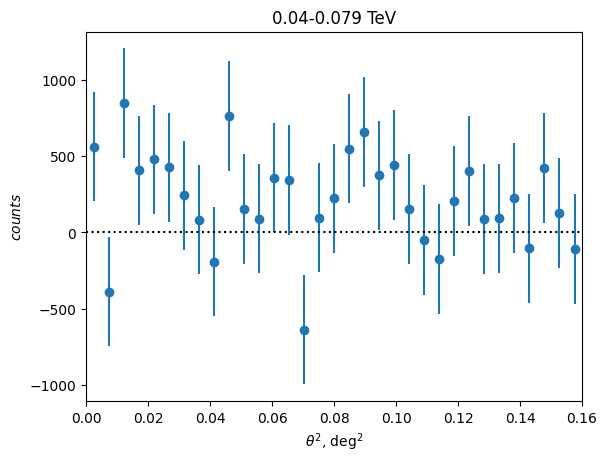

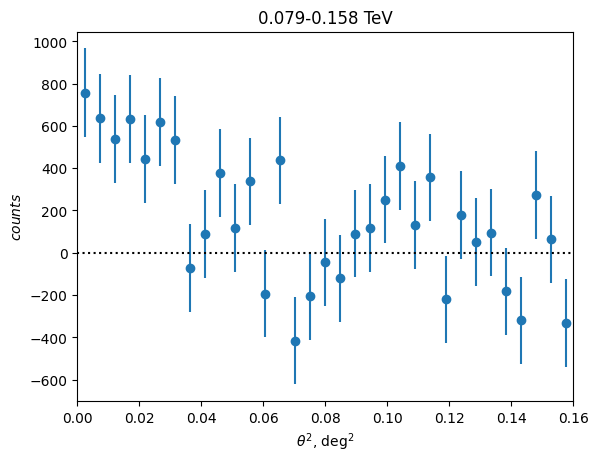

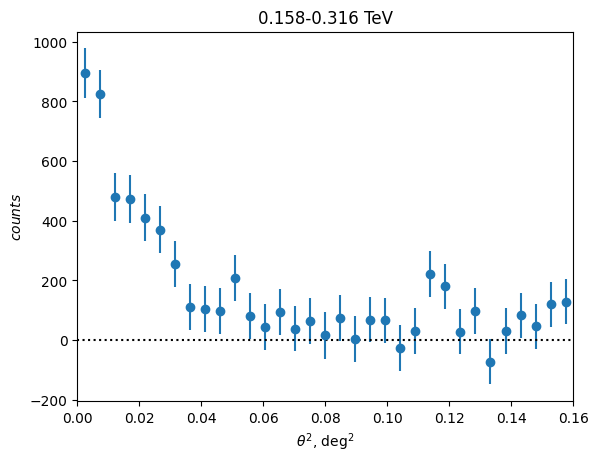

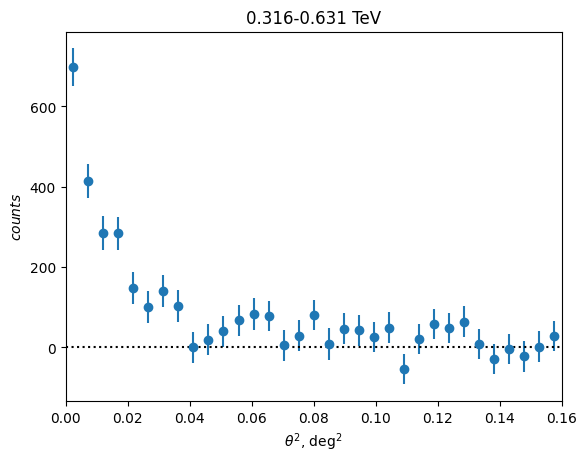

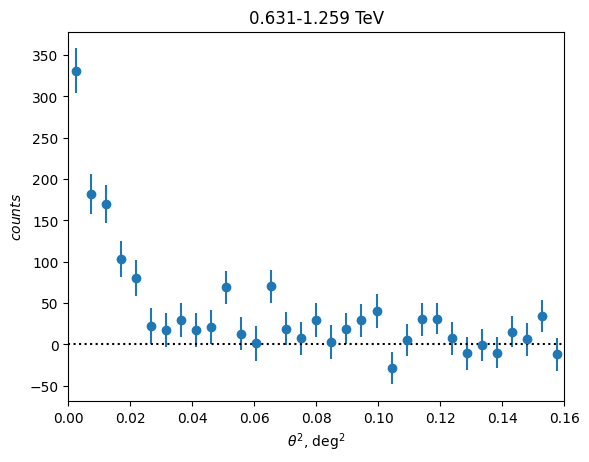

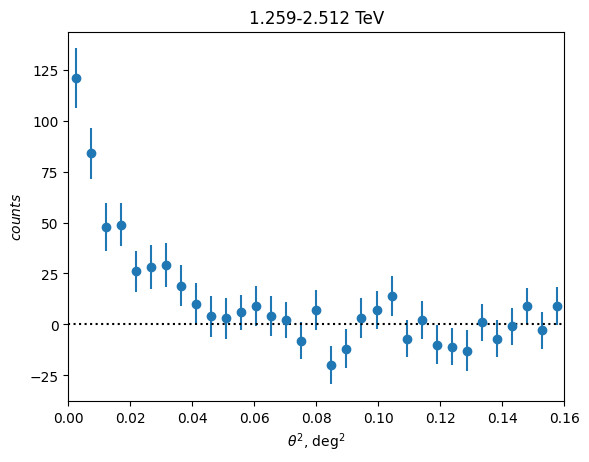

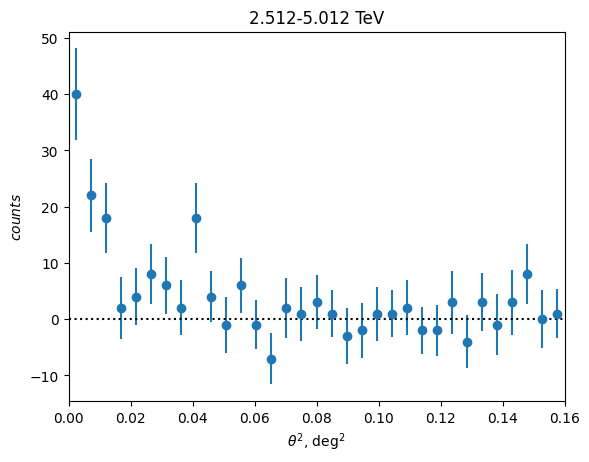

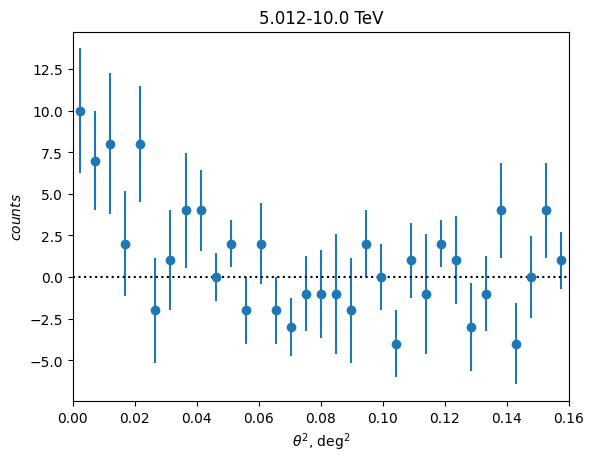

In [15]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)

for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [16]:
sigmas_ext = np.linspace(0.05, 0.5, 10)

In [22]:
def chi2(y, model, error):
    return np.sum(((y - model) / error) ** 2)

def fit_point_amplitude(y, error, point_template):
    #Weighted least-squares point-source amplitude, constrained >= 0.
    # it minimizes the chi2 np.sum(((y - amplitude * point_template) / error)**2)
    weights = 1.0 / error**2
    amplitude = np.sum(weights * point_template * y)
    amplitude /= np.sum(weights * point_template**2)
    return max(amplitude, 0.0)
    
def psf(th2, psf_params):
    return double_gaussian(th2, *psf_params)

def ext_convoluted(th2, sigma_ext, psf_params):
    ampl_tot, norm_t, sigma_c, sigma_t = psf_params
    
    sigma_c_conv = np.sqrt(sigma_c**2 + sigma_ext**2)
    sigma_t_conv = np.sqrt(sigma_t**2 + sigma_ext**2)
    c1 = sigma_c**2/sigma_c_conv**2
    c2 = norm_t*sigma_t**2/sigma_t_conv**2
    gauss_c_conv = c1 * np.exp(-th2 / (2 * sigma_c_conv**2))
    gauss_t_conv = c2 * np.exp(-th2 / (2 * sigma_t_conv**2))
    return gauss_c_conv + gauss_t_conv

In [23]:
def calculate_UL(
    cts,
    cts_err,
    th2,
    e,
    psf_fit_params,
    sigmas_ext,
    delta_chi2=2.71,
):
    cts = np.asarray(cts, dtype=float)
    cts_err = np.asarray(cts_err, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    e = np.asarray(e, dtype=float)
    sigmas_ext = np.asarray(sigmas_ext, dtype=float)

    flux_ratios = np.zeros((len(sigmas_ext), len(e)))

    for i, (y, yerr) in enumerate(zip(cts, cts_err)):
        psf_params = psf_fit_params[i]
        
        # Point-source PSF template normalized
        psf_template = psf(th2, psf_params)
        psf_template /= np.sum(psf_template)

        # Point-source-only fit
        point_amp = fit_point_amplitude(y, yerr, psf_template)
        point_model = point_amp * psf_template
        chi2_point = chi2(y, point_model, yerr)

        for k, sigma_ext in enumerate(sigmas_ext):
            # Extended-source template: PSF convolved with a Gaussian extension
            ext_template = ext_convoluted(th2, sigma_ext, psf_params)
            ext_template /= np.sum(ext_template)

            # Simultaneous fit of point and extended amplitudes.
            design_matrix = np.column_stack(
                [psf_template, ext_template]
            )

            weighted_matrix = design_matrix / yerr[:, None]
            weighted_data = y / yerr

            # Non-negative least square - minimizes chi2 of the source+ext model
            amplitudes, _ = nnls(weighted_matrix, weighted_data)
            point_amp_best, ext_amp_best = amplitudes

            best_model = (
                point_amp_best * psf_template
                + ext_amp_best * ext_template
            )

            chi2_min = chi2(y, best_model, yerr)
            target = chi2_min + delta_chi2

            # Profile chi-square:
            # Fix the extended amplitude and refit the point amplitude.
            def profile_chi2(ext_amp):
                residual_after_ext = y - ext_amp * ext_template
                
                point_amp = fit_point_amplitude(
                    residual_after_ext,
                    yerr,
                    psf_template,
                )
                point_amp = max(point_amp, 0.0)

                model = (
                    point_amp * psf_template
                    + ext_amp * ext_template
                )

                return chi2(y, model, yerr)

            # Find an upper bracket for the root.
            lower = ext_amp_best
            upper = max(2.0 * lower, 1.0)

            for _ in range(100):
                if profile_chi2(upper) >= target:
                    break
                upper *= 2.0
            else:
                raise RuntimeError(
                    "Could not bracket the extended-source upper limit."
                )

            # Solve profile_chi2(ext_amp) = chi2_min + delta_chi2.
            ext_amp_ul = brentq(
                lambda a: profile_chi2(a) - target,
                lower,
                upper,
            )

            # The templates are normalized to unit sum, so amplitudes are
            # directly equivalent to total model counts.
            total_best_counts = point_amp_best + ext_amp_best
            flux_ratios[k, i] = ext_amp_ul / np.maximum(total_best_counts, 1)

    return flux_ratios


In [24]:
flux_ratios = calculate_UL(
    cts,
    cts_err,
    th2,
    e,
    fit_params,
    sigmas_ext,
    delta_chi2=2.71,
)

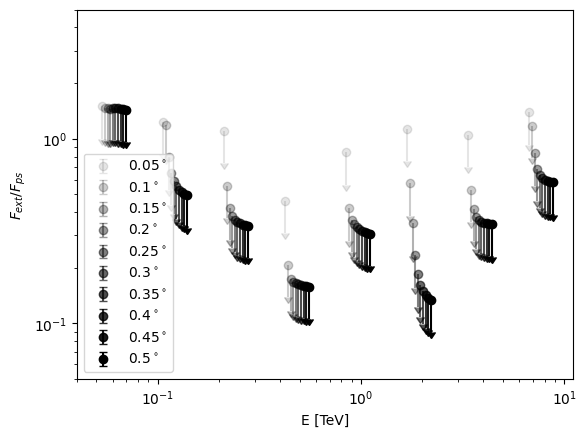

In [25]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.1+0.1*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.05, 5)
plt.legend()

In [ ]:
B0 = np.array([5, 10, 20, 40])*10**(-15) # G
lambda_b = 10 # kpc
E_mat = e[:, np.newaxis] # column
B0_mat = B0[np.newaxis, :] # row

E_prime = np.sqrt(E_mat/0.33)*20
delta = 5*10**(-7)*(20/E_prime)**(3/2)*(B0/10**(-18))*(lambda_b)**(1/2)
#delta = 3*10**(-6)*(B0/10**(-18))*(E_prime/20)**(-2)
D_gamma = 40*20/E_prime
tau = 130/D_gamma

#theta_theor = D_gamma*delta/130
#theta_theor = delta/tau
theta_theor = 0.07*(1+z)**(-1/2)*(tau/10)**(-1)*(E_mat/0.1)**(-3/4)*(B0/10**(-14))*(lambda_b)**(1/2)


plt.plot(np.log10(E_mat), theta_theor[:, 0], 'white', linewidth=2, label=f"B0 = {B0_mat[0,0]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 1], 'white', linewidth=2, linestyle='--', label=f"B0 = {B0_mat[0,1]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 2], 'white', linewidth=2, linestyle=':', label=f"B0 = {B0_mat[0,2]:.0e} G")
plt.plot(np.log10(E_mat), theta_theor[:, 3], 'white', linewidth=2, linestyle='-.', label=f"B0 = {B0_mat[0,3]:.0e} G")


plt.xlabel("log(E/TeV)")
plt.ylabel("θ, deg")
plt.legend()

plt.imshow(np.log10(flux_ratios), extent=[np.log10(e[0]), np.log10(e[-1]), sigmas_ext[0], sigmas_ext[-1]], aspect='auto', origin='lower')
plt.colorbar(label=r"$log(F_{ext}/F_{ps})$")
#plt.savefig(f'./images/UL_{name}_DC_COMPLETE.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
def extr_data_from_csv(filepath):
    tot_datapoints = 10
    data = np.genfromtxt(filepath, delimiter=",", skip_header=1)

    if data.size == 0:
        return np.zeros(tot_datapoints)

    if data.ndim == 1:
        values = data
    else:
        values = data[:, 1] if data.shape[1] > 1 else data[:, 0]

    if len(values) < tot_datapoints:
        values = np.append(values, np.zeros(tot_datapoints - len(values)))

    return values

In [ ]:
ext_sim_flux = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux.csv")
ext_sim_flux_up = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errup.csv")
ext_sim_flux_down = extr_data_from_csv("ext_sim_flux_data/ext_sim_flux_errdown.csv")

In [ ]:
from scipy.interpolate import RegularGridInterpolator
linestyles = ["-", "--", ":", "-."]
starting_relevancy = [10**(-1), 10**(-0.75), 10**(-0.5), 10**(-0.25)]
for i, col_idx in enumerate(range(len(B0))):
    logE = np.log10(E_mat[:, 0])
    theta_curve = theta_theor[:, col_idx]
    
    logE_grid = np.log10(E_mat[:, 0])
    sigma_grid = sigmas_ext
    
    interpolator = RegularGridInterpolator((sigma_grid, logE_grid), 
                                           np.log10(flux_ratios), 
                                           bounds_error=False, 
                                           fill_value=None)
    
    points = np.column_stack([theta_curve, logE])
    flux_ratios_on_curve = 10**interpolator(points)
    print(flux_ratios_on_curve)

    plt.plot(E_mat, flux_ratios_on_curve, color="black", alpha=1/(len(B0)+1)*(i+1), linestyle=linestyles[i])
    plt.errorbar(E_mat, flux_ratios_on_curve,np.abs(flux_ratios_on_curve/3), alpha=1/(len(B0)+1)*(i+1), uplims=True, linestyle='none',marker='o', label=f"B0 = {B0[i]:.0e} G",color='black')
plt.plot(E_mat[:, 0], ext_sim_flux, color="blue")
plt.fill_between(E_mat[:, 0], ext_sim_flux_down, ext_sim_flux_up, color='blue', alpha=0.3)
plt.ylim([0.005, 0.5])
plt.xlim([0.05, 5])
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$E$, TeV")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.legend()
plt.savefig(f'./images_thesis/UL_{Name}_LST_SIM_REMASTER.png', dpi=600, bbox_inches='tight')